In [1]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sb
import csv
from scipy import stats
from scipy.spatial.distance import cosine
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [2]:
with open("analytics.json", "r") as f:
    analytics = eval(f.read())

In [3]:
Counter([len(i) for i in analytics['participants'][33:]])

Counter({14: 84, 12: 33, 15: 1658})

In [4]:
participants = pd.read_csv("Cleaned_study_data.csv")
participants

,StartDate_post,EndDate_post,Status_post,IPAddress_post,Progress_post,Duration (in seconds)_post,Finished_post,RecordedDate_post,ResponseId_post,RecipientLastName_post,...,ih_dwell_p,mc_correct,n_op,n_comments,zip_state_match,speeder,commented,posted,passcode,gold_star
0,12/12/2023 10:34,12/12/2023 10:37,IP Address,71.71.112.54,100,217,True,12/12/2023 10:37,R_2ARnUkZ40c702IE,NaN,...,0.220734,1,1,2,1,0,1,1,True,0
1,12/12/2023 10:46,12/12/2023 10:52,IP Address,172.58.10.215,100,374,True,12/12/2023 10:52,R_27amtKO2JE7Iho9,NaN,...,0.109973,1,1,1,1,1,1,1,True,1
2,12/12/2023 10:47,12/12/2023 10:56,IP Address,66.212.218.70,100,520,True,12/12/2023 10:56,R_2Cy58sTvdtprJbm,NaN,...,0.141557,1,1,1,1,1,1,1,True,1
3,12/12/2023 10:55,12/12/2023 11:00,IP Address,68.116.85.163,100,260,True,12/12/2023 11:00,R_3QXJjMxRbpGVqnN,NaN,...,0.036418,1,1,1,1,1,1,1,True,1
4,12/12/2023 10:52,12/12/2023 11:06,IP Address,174.215.176.210,100,885,True,12/12/2023 11:06,R_2YLnKFzaVR8F7Mj,NaN,...,0.181847,1,1,1,1,1,1,1,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,12/12/2023 11:18,12/12/2023 11:25,IP Address,73.3.224.41,93,434,False,12/15/2023 0:33,R_1ddeajwrFRZrG73,NaN,...,0.092647,1,1,5,1,1,1,1,True,1
1039,12/12/2023 11:59,12/12/2023 12:02,IP Address,100.40.186.229,93,189,False,12/15/2023 0:33,R_27fMb9wZPSEktas,NaN,...,0.342752,1,0,4,1,1,0,1,True,0
1040,12/12/2023 11:32,12/12/2023 11:35,IP Address,172.56.15.42,93,197,False,12/15/2023 0:33,R_2ZKzyLxSf1s9NeJ,NaN,...,0.209302,1,1,1,1,1,1,1,True,1
1041,12/13/2023 13:25,12/13/2023 13:29,IP Address,24.99.26.176,93,222,False,12/15/2023 0:33,R_15KKEVD99jKy9Di,NaN,...,0.000000,1,1,5,1,1,1,1,True,1


In [6]:
ids = set(participants.participant_code)

In [7]:
analytics = [i for i in analytics['participants'] if len(i) == 15]
analytics = [i for i in analytics if i['participantCode'].lower() in ids]
len(analytics)

1043

In [10]:
analytics[0]

{'isAutoFollowingDisabled': False,
 'following': 0,
 'followers': 2,
 'qualified': True,
 'tags': [],
 '_id': '657896b96d158d001f181516',
 'study': '654d3200f18dbd001f7a8515',
 'user': '657896b96d158d001f18150f',
 'participantCode': '8GCH37',
 'profileNumber': 173,
 '__v': 0,
 'exitSurveySchedule': '2023-12-12T17:34:10.943Z',
 'finishedOnboardingSurveyAt': '2023-12-12T17:24:10.943Z',
 'treatmentArm': '654eaf90ae0ef3001e0a82b8',
 'analytics': [{'_id': '657897506d158d001f181c53',
   'module': 'posts',
   'participant': '657896b96d158d001f181516',
   'study': '654d3200f18dbd001f7a8515',
   'meta': {'description': 'User dwell time on post',
    'timestamp': '2023-12-12T17:24:30.455Z',
    'postId': '654e2ecbf18dbd001f7aaebe',
    'dwellTimeInSeconds': 18},
   '__v': 0,
   'createdAt': '2023-12-12T17:24:32.204Z',
   'updatedAt': '2023-12-12T17:24:32.204Z'},
  {'_id': '657897506d158d001f181c54',
   'module': 'posts',
   'participant': '657896b96d158d001f181516',
   'study': '654d3200f18dbd00

In [11]:
frmt = '%Y-%m-%dT%H:%M:%S'
start_times = {i['participantCode'].lower(): datetime.strptime(i['finishedOnboardingSurveyAt'].split('.')[0], frmt) for i in analytics}

In [68]:
posts = pd.read_csv("participant_content.csv")
content = posts[posts.userContent == 1]
content

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,dynamicContent,postOrCommentText,postOrCommentDate,postLikes,postDislikes,participantLiked,participantDisliked,parentPost,previousCommentOrPost,dwellTimeInSeconds
44,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,0,Yes! People are so closed-minded. America was ...,2023-12-12T17:28:03.930Z,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aaf46,654e2ecbf18dbd001f7aaf46,0
95,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,0,0,As if there aren’t millions of citizens using ...,2023-12-12T17:32:53.700Z,NaN,NaN,NaN,NaN,654e2ecdf18dbd001f7ab3ec,654e2ecdf18dbd001f7ab3ec,0
103,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,0,0,Most Americans wouldn’t be able to pass the im...,2023-12-12T17:26:05.474Z,5.0,1.0,0.0,0.0,NaN,NaN,66
184,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789b036d158d001f188a87,1,0,0,I honestly think people should have to have a ...,2023-12-12T17:40:19.333Z,6.0,4.0,0.0,0.0,NaN,NaN,105
185,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789bb66d158d001f18b972,1,0,0,People's rights are infringed every day. Felo...,2023-12-12T17:43:18.590Z,NaN,NaN,NaN,NaN,65789b036d158d001f188a87,65789b036d158d001f188a87,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104317,657b61122855e7001f93f0ef,imm_control3,pqdpcp,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Cbros,NaN,Baba,657b62628b12dc001f05d62b,1,0,0,"20,000,000 illegal immigrants this year alone",2023-12-14T20:15:32.087Z,3.0,3.0,0.0,0.0,NaN,NaN,0
104351,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b65a88b12dc001f069f70,1,0,0,Our society is being washed away right in fron...,2023-12-14T20:29:28.539Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,655d0ae8f1c1b5001f5cb577,0
104353,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66162855e7001f9554e3,1,0,0,I can agree with that but there needs to be a ...,2023-12-14T20:31:18.583Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,657b65bd8b12dc001f06b363,0
104407,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66cb8b12dc001f07eca7,1,0,0,"The over crowding, congestion and increased de...",2023-12-14T20:34:19.040Z,0.0,3.0,0.0,0.0,NaN,NaN,0


In [69]:
def rel_time(r):
    start_t = start_times[r['participantCode']]
    post_t = datetime.strptime(r['postOrCommentDate'].split('.')[0], frmt)
    return (post_t - start_t).total_seconds()/60

In [70]:
content['rel_time'] = content.apply(rel_time, axis=1)

C:\Users\Austin\AppData\Local\Temp\ipykernel_19004\839937186.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  content['rel_time'] = content.apply(rel_time, axis=1)


In [71]:
content

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,...,postOrCommentText,postOrCommentDate,postLikes,postDislikes,participantLiked,participantDisliked,parentPost,previousCommentOrPost,dwellTimeInSeconds,rel_time
44,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,...,Yes! People are so closed-minded. America was ...,2023-12-12T17:28:03.930Z,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aaf46,654e2ecbf18dbd001f7aaf46,0,3.883333
95,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,0,...,As if there aren’t millions of citizens using ...,2023-12-12T17:32:53.700Z,NaN,NaN,NaN,NaN,654e2ecdf18dbd001f7ab3ec,654e2ecdf18dbd001f7ab3ec,0,8.716667
103,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,0,...,Most Americans wouldn’t be able to pass the im...,2023-12-12T17:26:05.474Z,5.0,1.0,0.0,0.0,NaN,NaN,66,1.916667
184,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789b036d158d001f188a87,1,0,...,I honestly think people should have to have a ...,2023-12-12T17:40:19.333Z,6.0,4.0,0.0,0.0,NaN,NaN,105,4.283333
185,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,SFon85,NaN,"Hello, I'm a 38 year old married man. I love ...",65789bb66d158d001f18b972,1,0,...,People's rights are infringed every day. Felo...,2023-12-12T17:43:18.590Z,NaN,NaN,NaN,NaN,65789b036d158d001f188a87,65789b036d158d001f188a87,0,7.266667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104317,657b61122855e7001f93f0ef,imm_control3,pqdpcp,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Cbros,NaN,Baba,657b62628b12dc001f05d62b,1,0,...,"20,000,000 illegal immigrants this year alone",2023-12-14T20:15:32.087Z,3.0,3.0,0.0,0.0,NaN,NaN,0,1.033333
104351,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b65a88b12dc001f069f70,1,0,...,Our society is being washed away right in fron...,2023-12-14T20:29:28.539Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,655d0ae8f1c1b5001f5cb577,0,1.666667
104353,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66162855e7001f9554e3,1,0,...,I can agree with that but there needs to be a ...,2023-12-14T20:31:18.583Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,657b65bd8b12dc001f06b363,0,3.500000
104407,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Shan,NaN,"Jersey girl, born and raised!!! I love animals...",657b66cb8b12dc001f07eca7,1,0,...,"The over crowding, congestion and increased de...",2023-12-14T20:34:19.040Z,0.0,3.0,0.0,0.0,NaN,NaN,0,6.516667


In [72]:
op = content[pd.isnull(content.parentPost)]
comments = content[pd.notnull(content.parentPost)]

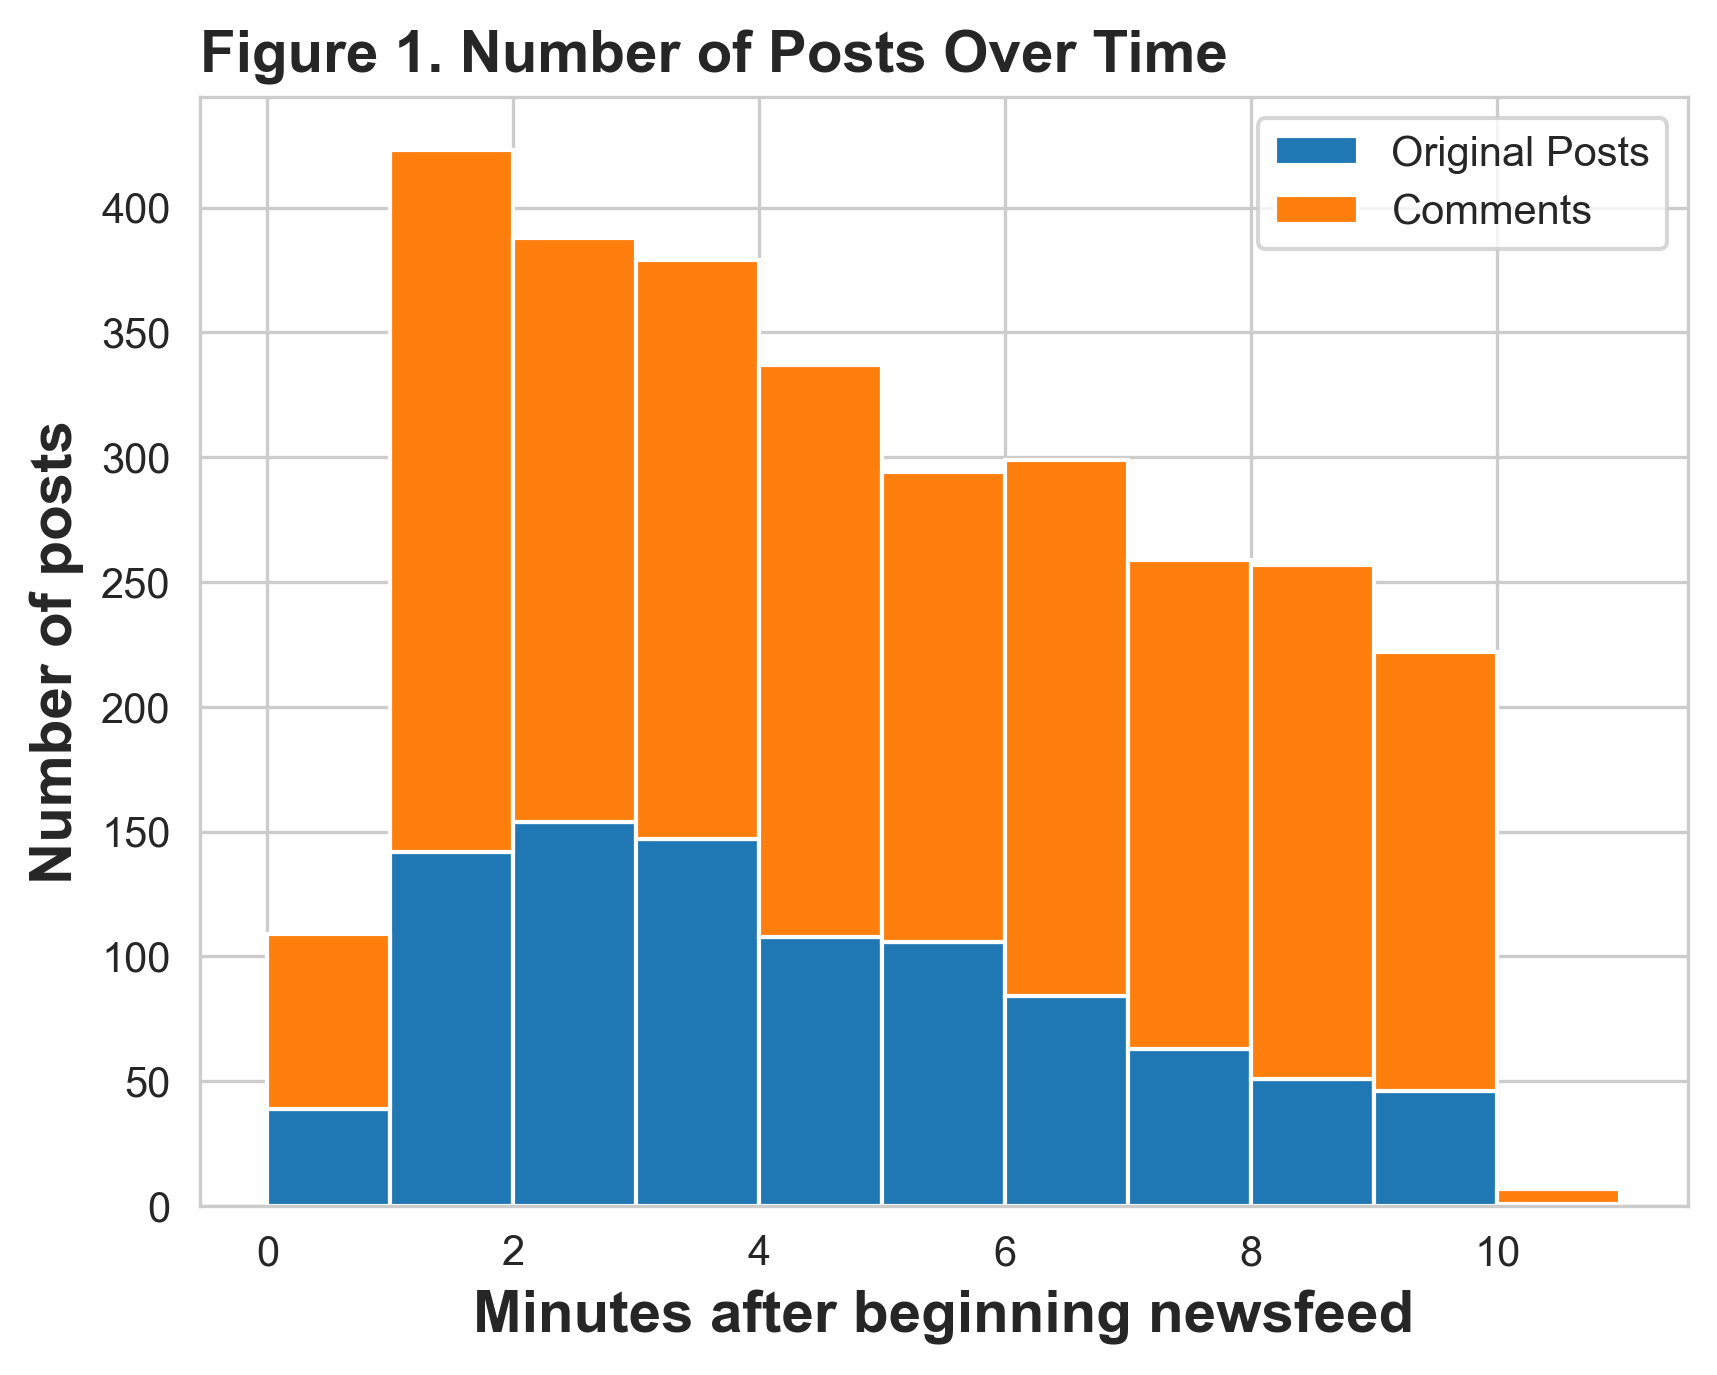

In [113]:
plt.figure(dpi=300)
sb.set_style("whitegrid")
plt.hist([op.rel_time, comments.rel_time],bins=[0,1,2,3,4,5,6,7,8,9,10,11], 
         label=["Original Posts", "Comments"], histtype="barstacked")
plt.xlabel("Minutes after beginning newsfeed", fontweight="bold",size=14)
plt.ylabel("Number of posts", fontweight="bold",size=14)
plt.legend()
plt.title("Figure 1. Number of Posts Over Time", loc="left", fontweight="bold",size=14)
plt.savefig("PostsOverTime.png")
plt.show()


In [74]:
len([i for i in Counter(op.participantCode).items() if i[1] > 1])

56

In [75]:
len([ i for i in content.groupby("participantCode").size() if i > 1])

836

In [76]:
content[content.participantCode == '8gch37']

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,...,postOrCommentText,postOrCommentDate,postLikes,postDislikes,participantLiked,participantDisliked,parentPost,previousCommentOrPost,dwellTimeInSeconds,rel_time
44,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,0,...,Yes! People are so closed-minded. America was ...,2023-12-12T17:28:03.930Z,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aaf46,654e2ecbf18dbd001f7aaf46,0,3.883333
95,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,0,...,As if there aren’t millions of citizens using ...,2023-12-12T17:32:53.700Z,NaN,NaN,NaN,NaN,654e2ecdf18dbd001f7ab3ec,654e2ecdf18dbd001f7ab3ec,0,8.716667
103,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,0,...,Most Americans wouldn’t be able to pass the im...,2023-12-12T17:26:05.474Z,5.0,1.0,0.0,0.0,NaN,NaN,66,1.916667


In [80]:
bot_comments = (posts[(posts.dynamicContent == 1) & pd.notnull(posts.parentPost)])
bot_comments

,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,staticContent,dynamicContent,postOrCommentText,postOrCommentDate,postLikes,postDislikes,participantLiked,participantDisliked,parentPost,previousCommentOrPost,dwellTimeInSeconds
45,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,velvet_vanity,NaN,Progressive and proud. stirring up trouble for...,657898396d158d001f183c87,0,0,1,Absolutely! The diversity and contributions br...,2023-12-12T17:28:25.112Z,NaN,NaN,NaN,NaN,654e2ecbf18dbd001f7aaf46,657898246d158d001f18395d,0
96,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,swifty_123,NaN,"Stirring the pot, raising eyebrows, and speaki...",6578995b6d158d001f186229,0,0,1,"And that's the problem, isn't it? We need to p...",2023-12-12T17:33:15.569Z,NaN,NaN,NaN,NaN,654e2ecdf18dbd001f7ab3ec,657899456d158d001f185f72,0
186,6578987d6d158d001f1847ac,gc_control3,nyuhem,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Anderson.78,NaN,"Old-school values, unfiltered opinions. No non...",65789bcc6d158d001f18c1b6,0,0,1,"I agree, stripping away someone's gun rights f...",2023-12-12T17:43:40.240Z,NaN,NaN,NaN,NaN,65789b036d158d001f188a87,65789bb66d158d001f18b972,0
207,6578998a6d158d001f18687e,imm_control2,gw6r7f,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,melody.89,NaN,Community and the civic engagement.,65789b656d158d001f18a6ca,0,0,1,It's crazy how we're supposed to accommodate i...,2023-12-12T17:41:57.113Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb4d5,65789b506d158d001f18a0ee,0
342,65789a9c6d158d001f187d86,imm_control1,hfyv7m,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,melody.89,NaN,Community and the civic engagement.,65789be96d158d001f18c9c1,0,0,1,"I understand that diversity is important, but ...",2023-12-12T17:44:09.377Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb4c6,65789bd36d158d001f18c3d1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104231,657b58d12855e7001f932c5f,imm_control3,qby6gb,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,open.road,NaN,Drain the swamp! Trump 2024!,657b5a4f2855e7001f9361f9,0,0,1,Immigration is crucial for our country's growt...,2023-12-14T19:41:03.114Z,NaN,NaN,NaN,NaN,657b59e62855e7001f93527a,657b5a392855e7001f935f31,0
104265,657b61122855e7001f93f0ef,imm_control3,pqdpcp,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,enigma.897,NaN,Putting empathy into motion for a brighter tom...,657b62e58b12dc001f05e73b,0,0,1,"I respect your opinion, but it's important to ...",2023-12-14T20:17:41.027Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,657b62cf8b12dc001f05e450,0
104352,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,enigma.897,NaN,Putting empathy into motion for a brighter tom...,657b65bd8b12dc001f06b363,0,0,1,We must remember that not all immigrants are a...,2023-12-14T20:29:49.823Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,657b65a88b12dc001f069f70,0
104354,657b64a78b12dc001f06215b,imm_control3,h63zav,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,enigma.897,NaN,Putting empathy into motion for a brighter tom...,657b662c2855e7001f956e82,0,0,1,I understand the concern about managing the nu...,2023-12-14T20:31:40.010Z,NaN,NaN,NaN,NaN,655d0ae8f1c1b5001f5cb577,657b66162855e7001f9554e3,0


In [81]:
bot_commented = set(bot_comments.parentPost)

In [104]:
content['bot_likes'] = content.postLikes - content.participantLiked
content['bot_dislikes'] = content.postDislikes - content.participantDisliked


C:\Users\Austin\AppData\Local\Temp\ipykernel_19004\33520733.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  content['bot_likes'] = content.postLikes - content.participantLiked
C:\Users\Austin\AppData\Local\Temp\ipykernel_19004\33520733.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  content['bot_dislikes'] = content.postDislikes - content.participantDisliked


AttributeError: QuadMesh.set() got an unexpected keyword argument 'annot'

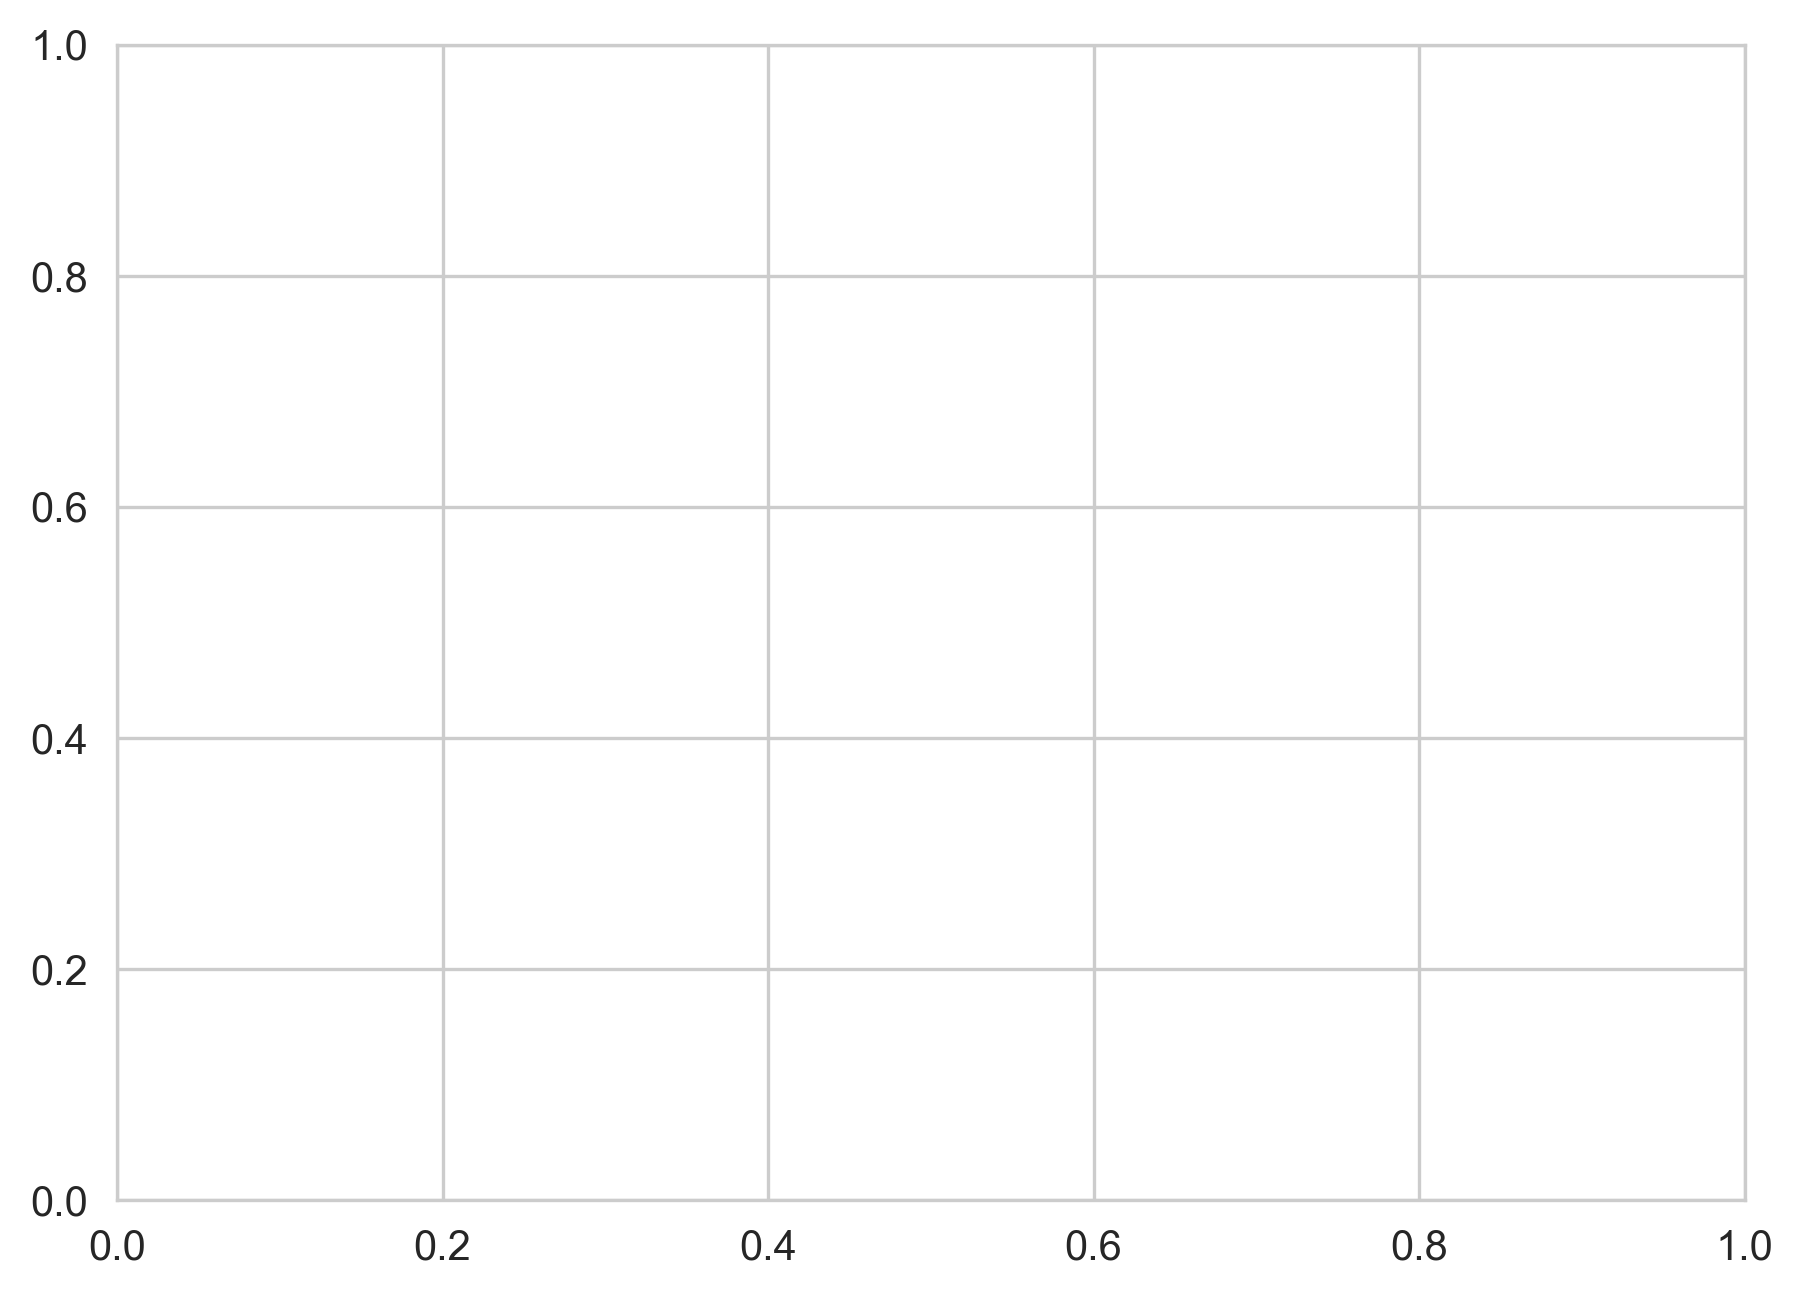

In [114]:
plt.figure(figsize=(7,5), dpi=300)
sb.histplot(content, x="bot_likes", y="bot_dislikes",
           bins=[[i for i in range(17)],
                 [i for i in range(12)]],
           cbar=True, cbar_kws=dict(shrink=.75),
           annot=True)
plt.xlabel("# Bot Likes", fontweight="bold",size=14)
plt.ylabel("# Bot Dislikes", fontweight="bold",size=14)
plt.title("Figure 2. Bot Dis/liking Behavior", loc="left", fontweight="bold",size=14)
plt.savefig("bot_engagement.png")
plt.show()

In [106]:
content['bot_engaged'] = content.apply(lambda x: 1 if (x.postOrCommentId in bot_commented) or ((x.bot_likes + x.bot_dislikes) > 1) else 0, axis=1)

C:\Users\Austin\AppData\Local\Temp\ipykernel_19004\124987201.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  content['bot_engaged'] = content.apply(lambda x: 1 if (x.postOrCommentId in bot_commented) or ((x.bot_likes + x.bot_dislikes) > 1) else 0, axis=1)


In [107]:
len(op)

941

In [108]:
len(content[content.bot_engaged == 1])

856

In [111]:
content[content.participantCode == "8gch37"].sort_values('rel_time').reset_index()

,index,sessionId,treatmentArm,participantCode,profilePicture,firstName,lastName,bio,postOrCommentId,userContent,...,postDislikes,participantLiked,participantDisliked,parentPost,previousCommentOrPost,dwellTimeInSeconds,rel_time,bot_likes,bot_dislikes,bot_engaged
0,103,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657897ad6d158d001f1824be,1,...,1.0,0.0,0.0,NaN,NaN,66,1.916667,5.0,1.0,1
1,44,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657898246d158d001f18395d,1,...,NaN,NaN,NaN,654e2ecbf18dbd001f7aaf46,654e2ecbf18dbd001f7aaf46,0,3.883333,NaN,NaN,0
2,95,657896b96d158d001f181516,imm_treat,8gch37,https://sma2-prod.s3.amazonaws.com/animal%2C%2...,Yelena22,NaN,NC girl,657899456d158d001f185f72,1,...,NaN,NaN,NaN,654e2ecdf18dbd001f7ab3ec,654e2ecdf18dbd001f7ab3ec,0,8.716667,NaN,NaN,0


In [112]:
count = 0

for id in set(content['participantCode']):
    small_df = content[content.participantCode == id].sort_values("rel_time").reset_index()
    engaged = False
    c = True
    for ind, row in small_df.iterrows():
        # Only consider if you haven't counted them yet
        if c:
            if engaged:
                # If they were previously engaged, then count them and stop counting them
                count += 1
                c = False
            else:
                if row.bot_engaged:
                    engaged = True
                
        
count

566